In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv


✓ Found dataset at: /kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv
✓ Dataset Shape: (920, 16)
✓ Cleaned 1759 missing rows.
✓ Target column identified: 'num'

========== Logistic Regression Performance ==========
Accuracy:  0.8500
Precision: 0.9130
Recall:    0.7500
F1-Score:  0.8235

========== Decision Tree Performance ==========
Accuracy:  0.8000
Precision: 0.8077
Recall:    0.7500
F1-Score:  0.7778


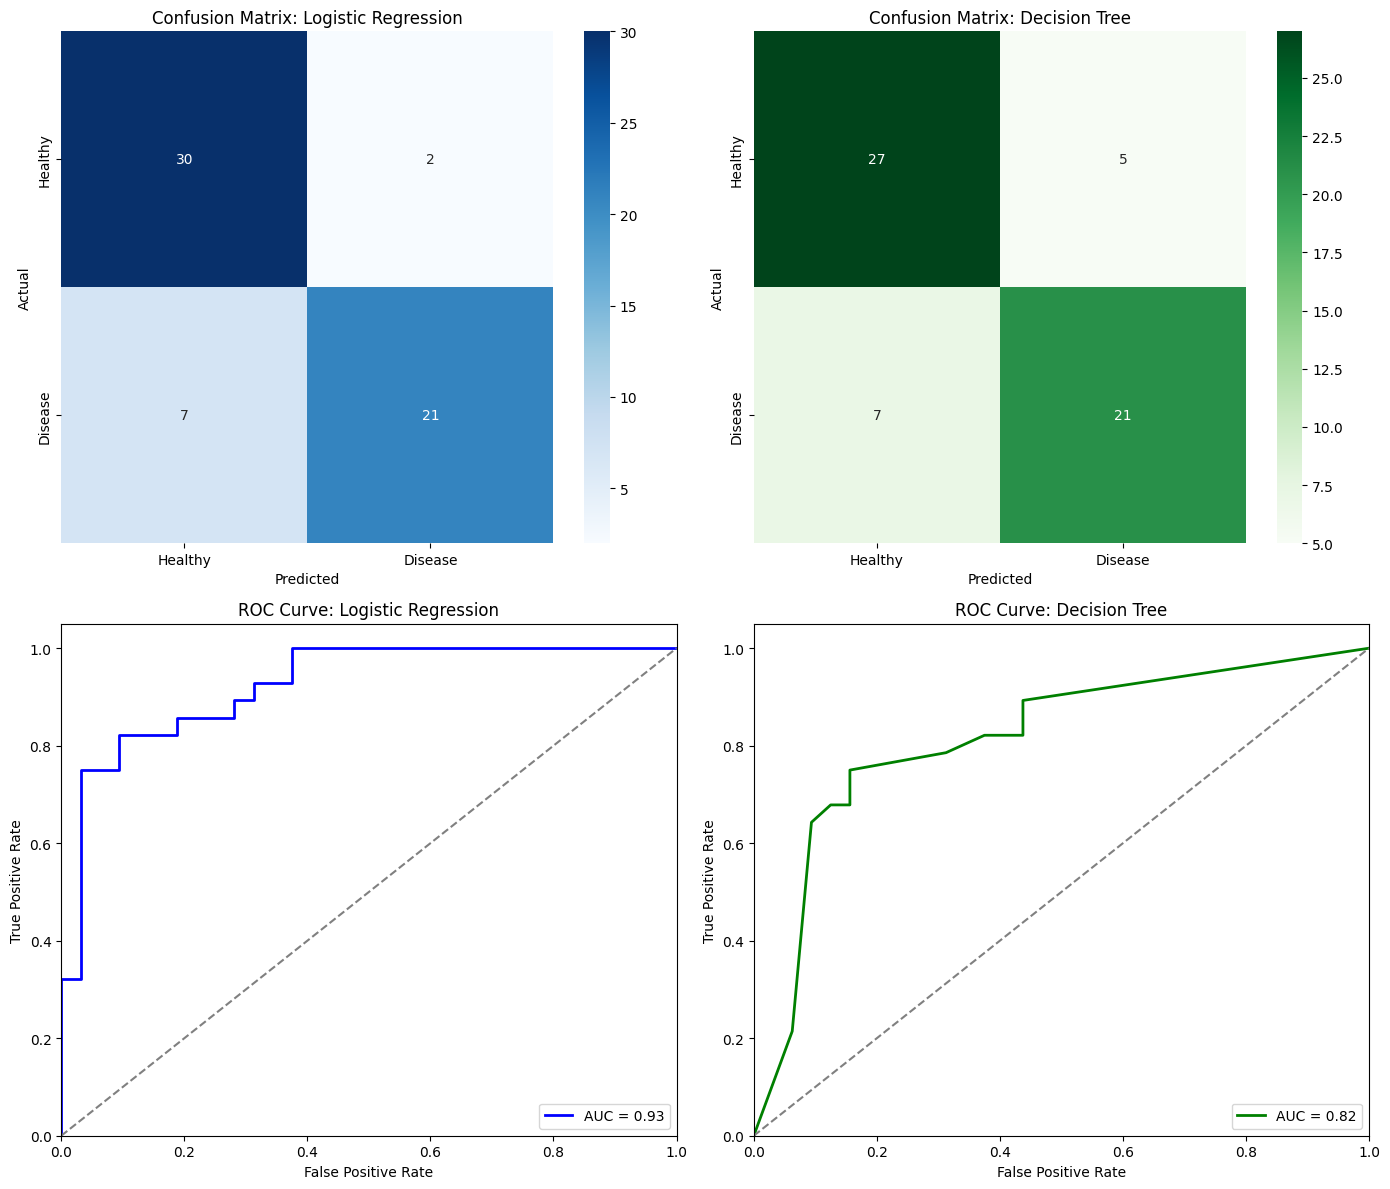

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

# ----------------------------------------------------
# Step 1: Automatically Find and Load the CSV File
# ----------------------------------------------------
csv_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.csv'):
            csv_path = os.path.join(root, file)
            break
    if csv_path:
        break

if csv_path:
    print(f"✓ Found dataset at: {csv_path}")
    df = pd.read_csv(csv_path)
    print(f"✓ Dataset Shape: {df.shape}")
else:
    print("✗ Error: No CSV file found in /kaggle/input. Please add the dataset to the notebook.")
    df = pd.DataFrame()

if not df.empty:
    # ----------------------------------------------------
    # Step 2: Data Cleaning & Feature Scaling
    # ----------------------------------------------------
    # Handle missing values
    missing_vals = df.isnull().sum().sum()
    if missing_vals > 0:
        df = df.dropna()
        print(f"✓ Cleaned {missing_vals} missing rows.")
        
    # Dynamically locate the target column
    target_col = 'target' if 'target' in df.columns else ('num' if 'num' in df.columns else df.columns[-1])
    print(f"✓ Target column identified: '{target_col}'")
    
    # Standardize target to binary (0 = Healthy, 1 = Heart Disease)
    if df[target_col].nunique() > 2:
        df[target_col] = df[target_col].apply(lambda x: 1 if x > 0 else 0)
        
    # Isolate numeric features
    X = df.drop(columns=[target_col]).select_dtypes(include=[np.number])
    y = df[target_col].astype(int)
    
    # Train-Test Split (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Scale features for Logistic Regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # ----------------------------------------------------
    # Step 3: Train and Evaluate Models
    # ----------------------------------------------------
    def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name):
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None
        
        print(f"\n========== {model_name} Performance ==========")
        print(f"Accuracy:  {accuracy_score(y_te, y_pred):.4f}")
        print(f"Precision: {precision_score(y_te, y_pred):.4f}")
        print(f"Recall:    {recall_score(y_te, y_pred):.4f}")
        print(f"F1-Score:  {f1_score(y_te, y_pred):.4f}")
        return y_pred, y_prob

    # Logistic Regression
    lr_pred, lr_prob = evaluate_model(
        LogisticRegression(random_state=42, max_iter=1000), 
        X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression"
    )
    
    # Decision Tree
    dt_pred, dt_prob = evaluate_model(
        DecisionTreeClassifier(max_depth=5, random_state=42), 
        X_train, X_test, y_train, y_test, "Decision Tree"
    )

    # ----------------------------------------------------
    # Step 4: Visualizations
    # ----------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # Confusion Matrix: Logistic Regression
    sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
                xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
    axes[0, 0].set_title('Confusion Matrix: Logistic Regression')
    axes[0, 0].set_xlabel('Predicted')
    axes[0, 0].set_ylabel('Actual')
    
    # Confusion Matrix: Decision Tree
    sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', cmap='Greens', ax=axes[0, 1],
                xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
    axes[0, 1].set_title('Confusion Matrix: Decision Tree')
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Actual')
    
    # ROC Curve: Logistic Regression
    if lr_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, lr_prob)
        axes[1, 0].plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc(fpr, tpr):.2f}')
    axes[1, 0].plot([0, 1], [0, 1], color='gray', linestyle='--')
    axes[1, 0].set_xlim([0.0, 1.0])
    axes[1, 0].set_ylim([0.0, 1.05])
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].set_title('ROC Curve: Logistic Regression')
    axes[1, 0].legend(loc="lower right")
    
    # ROC Curve: Decision Tree
    if dt_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, dt_prob)
        axes[1, 1].plot(fpr, tpr, color='green', lw=2, label=f'AUC = {auc(fpr, tpr):.2f}')
    axes[1, 1].plot([0, 1], [0, 1], color='gray', linestyle='--')
    axes[1, 1].set_xlim([0.0, 1.0])
    axes[1, 1].set_ylim([0.0, 1.05])
    axes[1, 1].set_xlabel('False Positive Rate')
    axes[1, 1].set_ylabel('True Positive Rate')
    axes[1, 1].set_title('ROC Curve: Decision Tree')
    axes[1, 1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()